<a href="https://colab.research.google.com/github/Yusuf-Sonmez/Siesmic_Activity_Detectec/blob/main/Caltech101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchinfo

import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms , datasets
from torchinfo import summary
from torch.utils.data import DataLoader,Subset

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [ ]:
device

'cuda'

In [ ]:
IMG_SIZE = 224
seed=42

In [ ]:
def to_rgb (img):
  return img.convert("RGB")

In [ ]:
train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.6,1.0),ratio=(0.75,1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.5,scale=(0.02,0.15),ratio=(0.3,3.3), value="random")

    ])

In [ ]:
test_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
    ])

In [ ]:
from torch.utils.data import random_split
root = "./data"
test_ratio = 0.2

In [ ]:
ds_train_full = datasets.Caltech101( root=root, download=True, transform= train_tf)
ds_test_full = datasets.Caltech101( root=root, download=True, transform= test_tf)

In [ ]:
n_total = len(ds_train_full)
n_test = int(n_total * test_ratio)
n_train = n_total - n_test

In [ ]:
n_total , n_test , n_train

(8677, 1735, 6942)

In [ ]:
g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_total,generator=g).tolist()

In [ ]:
train_idx = perm[:n_train]
test_idx =perm[n_train:]

In [ ]:
len(train_idx) , len(test_idx)

(6942, 1735)

In [ ]:
train_ds = Subset(ds_train_full,train_idx)
test_ds = Subset(ds_test_full,test_idx)

In [ ]:
len(train_ds) , len(test_ds)

(6942, 1735)

In [ ]:
import os
BATCH_SIZE = 16
train_dataloader = DataLoader(train_ds,batch_size=BATCH_SIZE,
                              shuffle=True,
                              pin_memory=True,
                              num_workers=2)
test_dataloader = DataLoader(test_ds,batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=2,
                             pin_memory=True)

In [ ]:
class_names = ds_train_full.categories

In [ ]:
img , label = ds_train_full[6000]

In [ ]:
print(label)
print(ds_train_full.categories[label])

56
lamp


In [ ]:
print(class_names)

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

In [ ]:
height = 224
width = 224
color_chanels = 3
patch_size = 16

number_of_patches = (height * width) / (patch_size ** 2)

In [ ]:
number_of_patches

196.0

In [ ]:
embedding_layer_input_shape = (height,width,color_chanels)
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_chanels)

print(embedding_layer_input_shape)
print(embedding_layer_output_shape)

(224, 224, 3)
(196.0, 768)


In [ ]:
image , label = test_dataloader.dataset[50]

Text(0.5, 1.0, 'llama')

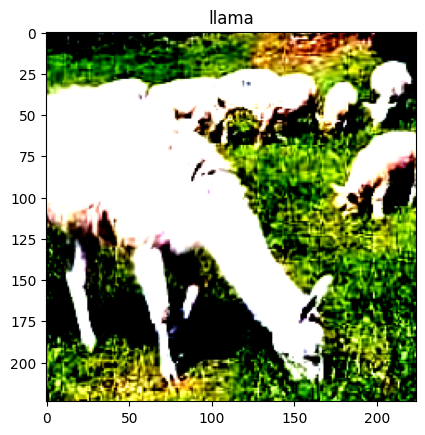

In [ ]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])

Number of patches per row: 14        
Number of patches per column: 14        
Total patches: 196        
Patch size: 16 pixels x 16 pixels


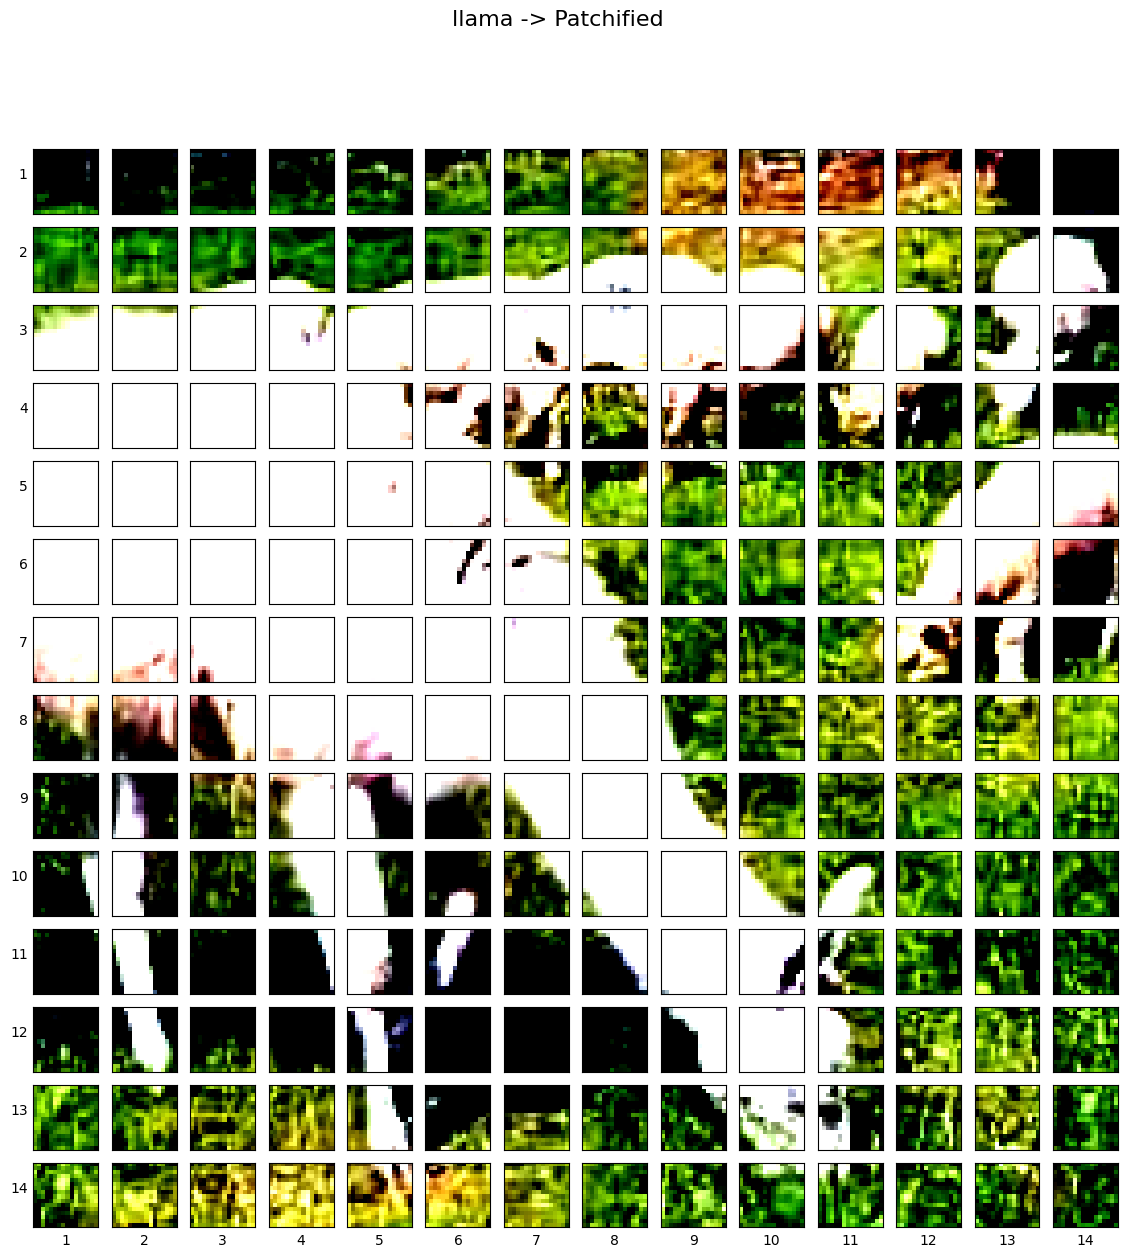

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Önce görseli permute ediyoruz
image_permuted = image.permute(1, 2, 0)
img_size = 224
patch_size = 16
# float hatasını önlemek için int'e çeviriyoruz
num_patches = int(img_size / patch_size)

assert img_size % patch_size == 0, "Image size must be divisible by patch size"

print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Subplot oluşturma
fig, axs = plt.subplots(nrows=num_patches,
                        ncols=num_patches,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

for i, patch_height in enumerate(range(0, img_size, patch_size)):
    for j, patch_width in enumerate(range(0, img_size, patch_size)):

        # Patch'i seçiyoruz
        patch = image_permuted[patch_height:patch_height+patch_size,
                               patch_width:patch_width+patch_size,
                               :]

        # DÜZELTME: Veriyi numpy'a çevirip 0-1 arasına clip ediyoruz
        # Eğer veri zaten GPU'daysa .cpu() eklemek güvenlidir
        plot_ready_patch = np.clip(patch.cpu().numpy(), 0, 1)

        axs[i, j].imshow(plot_ready_patch)

        # Eksen ayarları
        axs[i, j].set_ylabel(i+1, rotation="horizontal", horizontalalignment="right")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [ ]:
patch_size=16

conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

In [ ]:
image_out_of_conv = conv2d(image.unsqueeze(0))

In [ ]:
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

In [ ]:
flatten = nn.Flatten(start_dim=2,end_dim=3)

In [ ]:
image_out_of_conv_flattened = flatten(image_out_of_conv)

In [ ]:
image_out_of_conv_flattened.shape

torch.Size([1, 768, 196])

In [ ]:
image_out_of_conv_flattened.permute(0,2,1).shape

torch.Size([1, 196, 768])

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                 in_channels : int=3,
                 embedding_dim : int=768,
                 patch_size : int=16
                 ):
        super().__init__()

        self.patcher = nn.Conv2d(in_channels=3,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0
                                 )
        self.flatten = nn.Flatten(start_dim=2,end_dim=3)

    def forward(self,x):
        x_patcher = self.patcher(x)
        x_flattened = self.flatten(x_patcher)
        return x_flattened.permute(0,2,1)

In [ ]:
patch_embedding = PatchEmbedding(inchanels=3,  patch_size=16,embedding_dim = 768 )

TypeError: PatchEmbedding.__init__() got an unexpected keyword argument 'inchanels'

In [ ]:
patch_embedding_image =patch_embedding(image.unsqueeze(0))

TypeError: 'Tensor' object is not callable

In [ ]:
image.unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [ ]:
random_input_image = (1, 3, 224, 224)

summary(PatchEmbedding(),
         input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,         row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [ ]:
print(patch_embedding_image)

tensor([[[-0.3195, -0.2970,  1.4411,  ..., -0.5729,  0.7948,  0.6264],
         [ 0.0699, -0.2034,  1.0497,  ..., -0.2260,  0.5163,  0.0992],
         [ 0.3280, -0.3880,  0.8599,  ..., -0.3922,  0.9780,  0.0411],
         ...,
         [ 0.2480, -0.3740, -0.0387,  ..., -0.0438,  0.2003,  0.3619],
         [-0.4765, -0.3003, -0.0992,  ...,  0.3904, -0.3448, -0.2162],
         [ 0.0731, -0.5199, -0.1223,  ..., -0.1029,  0.2777,  0.0653]]],
       grad_fn=<PermuteBackward0>)


In [ ]:
patch_embedding_image.shape

torch.Size([1, 196, 768])

In [ ]:
batch_size = patch_embedding_image.shape[0]
embedding_dimension = patch_embedding_image.shape[-1]

class_token = nn.Parameter(torch.ones(batch_size,1,embedding_dimension),requires_grad=True)

print(class_token.shape)

torch.Size([1, 1, 768])


In [ ]:
#class_token

In [ ]:
patch_embedded_image_with_class_embedding = torch.cat((class_token,patch_embedding_image),dim=1)

In [ ]:
patch_embedded_image_with_class_embedding.shape

torch.Size([1, 197, 768])

In [ ]:
number_of_patches = int((height * width) / (patch_size ** 2))
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

position_embedding = nn.Parameter(torch.ones(1,number_of_patches+1,embedding_dimension),requires_grad=True)
print(position_embedding.shape)

torch.Size([1, 197, 768])


In [ ]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding

In [ ]:
patch_and_position_embedding.shape

torch.Size([1, 197, 768])

In [ ]:
patch_size = 16
height , weight = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f"input shape: {x.shape}")

patch_embedding_layer = PatchEmbedding(inchanels=3,  patch_size = patch_size ,embedding_dim = 768 )

patch_embedding = patch_embedding_layer(x)
print(f"patch embedding shape: {patch_embedding.shape}")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.randn(batch_size,1,embedding_dimension),requires_grad=True)

print(f"class token shape: {class_token.shape}")

patch_embedding_class_token = torch.cat((class_token, patch_embedding_image),dim=1)

print(f"patch embedding with class token shape: {patch_embedding_class_token.shape}")

number_of_patches = int((height * width) / (patch_size ** 2))
embedding_dimension = patch_embedding_class_token.shape[-1]

position_embedding = nn.Parameter(torch.randn(1,number_of_patches+1,embedding_dimension),requires_grad=True)
print(f"position embedding shape: {position_embedding.shape}")

patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"patch and position embedding shape: {patch_and_position_embedding.shape}")


input shape: torch.Size([1, 3, 224, 224])


TypeError: PatchEmbedding.__init__() got an unexpected keyword argument 'inchanels'

In [ ]:
class MultiheadAttention(nn.Module):
    def __init__(self,
                 embedding_dim : int=768,
                 num_heads : int=12,
                 attn_dropout : float=0.0
                 ):
      super().__init__()
      self.layer_norm = nn.LayerNorm(embedding_dim)

      self.multihead_attention = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                       num_heads=num_heads,
                                                       dropout=attn_dropout,
                                                       batch_first=True)

    def forward(self,x):
      x = self.layer_norm(x)
      attn_output, _ = self.multihead_attention(query=x,key=x,value=x,
                                                need_weights=False)
      return attn_output

In [ ]:
multihead_self_attention_block = MultiheadAttention()

In [ ]:
patch_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"patch_and_position_embedding: {patch_and_position_embedding.shape}")
print(f"patch_image_through_msa_block: {patch_image_through_msa_block.shape}")

patch_and_position_embedding: torch.Size([1, 197, 768])
patch_image_through_msa_block: torch.Size([1, 197, 768])


In [ ]:
class MLPBlock (nn.Module):
  def __init__(self,
               embedding_dim: int=768,
               mlp_size : int=3072,
               dropout : float=0.1):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape= embedding_dim)

    self.mlp = nn.Sequential(
        nn.Linear(in_features=embedding_dim,out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,out_features=embedding_dim),
        nn.Dropout(p=dropout)
    )

  def forward(self,x):
    x = self.layer_norm(x)
    x = self.mlp(x)
    return x

In [ ]:
mlp_blaock = MLPBlock()

patch_image_through_mlp_block = mlp_blaock(patch_image_through_msa_block)
print(f"patch_image_through_msa_block: {patch_image_through_msa_block.shape}")
print(f"patch_image_through_msa_block: {patch_image_through_mlp_block.shape}")

patch_image_through_msa_block: torch.Size([1, 197, 768])
patch_image_through_msa_block: torch.Size([1, 197, 768])


In [ ]:
patch_image_through_msa_block

tensor([[[ 0.1432, -0.0131, -0.0065,  ..., -0.2275, -0.2098, -0.0136],
         [ 0.1059, -0.0365,  0.0028,  ..., -0.1708, -0.1759, -0.0227],
         [ 0.1936,  0.0324,  0.0569,  ..., -0.2315, -0.0643,  0.0465],
         ...,
         [ 0.2053, -0.1345, -0.0330,  ..., -0.1644, -0.1962, -0.0645],
         [ 0.2301, -0.0418, -0.1637,  ..., -0.0988, -0.1504,  0.0380],
         [ 0.1740, -0.1283,  0.1014,  ..., -0.2081, -0.1063,  0.0182]]],
       grad_fn=<TransposeBackward0>)

In [ ]:
patch_image_through_mlp_block

tensor([[[-0.0659,  0.1415, -0.0831,  ..., -0.0000, -0.0166,  0.3346],
         [ 0.0677,  0.0737, -0.1192,  ..., -0.0950,  0.1545,  0.1233],
         [ 0.0170,  0.0000, -0.0942,  ..., -0.3173,  0.2426,  0.2451],
         ...,
         [-0.2314,  0.1098, -0.1400,  ..., -0.1774,  0.0540,  0.2022],
         [-0.1175,  0.1558, -0.0000,  ..., -0.1525, -0.0507,  0.1238],
         [-0.0541,  0.1176, -0.1601,  ..., -0.2651,  0.3383,  0.1884]]],
       grad_fn=<MulBackward0>)

In [ ]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embedding_dim : int=768,
               num_heads : int=12,
               attn_dropout : float=0.0,
               mlp_size : int=3072,
               mlp_dropout : float=0.1
                 ):
      super().__init__()

      self.msa_block = MultiheadAttention(embedding_dim=embedding_dim,
                                          num_heads=num_heads,
                                          attn_dropout=attn_dropout)

      self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                                mlp_size=mlp_size,
                                dropout=mlp_dropout)

  def forward(self, x):

      x =  self.msa_block(x) + x

      x = self.mlp_block(x) + x

      return x

In [ ]:
transformer_encoder_block = TransformerEncoderblock()

In [ ]:
summary(model = transformer_encoder_block,
         input_size=[1,197,768],
         col_names=["input_size", "output_size", "num_params", "trainable"],
      )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
TransformerEncoderblock                  [1, 197, 768]             [1, 197, 768]             --                        True
├─MultiheadAttention: 1-1                [1, 197, 768]             [1, 197, 768]             --                        True
│    └─LayerNorm: 2-1                    [1, 197, 768]             [1, 197, 768]             1,536                     True
│    └─MultiheadAttention: 2-2           --                        [1, 197, 768]             2,362,368                 True
├─MLPBlock: 1-2                          [1, 197, 768]             [1, 197, 768]             --                        True
│    └─LayerNorm: 2-3                    [1, 197, 768]             [1, 197, 768]             1,536                     True
│    └─Sequential: 2-4                   [1, 197, 768]             [1, 197, 768]             --                        True
│  

In [ ]:
torch_transformer_encoder_layer= nn.TransformerEncoderLayer(d_model=768,
                           nhead=12,
                           dim_feedforward=3072,
                           dropout=0.1,
                           activation="gelu",
                           batch_first=True,
                           norm_first=True)

In [ ]:
class ViT(nn.Module):

    def __init__(self,
                 img_size:int=224,
                 in_channels:int=3,
                 patch_size:int=16,
                 num_transformer_layers:int=12,
                 embedding_dim:int=768,
                 mlp_size:int=3072,
                 num_heads:int=12,
                 attn_dropout:float=0,
                 mlp_dropout:float=0.1,
                 embedding_dropout:float=0.1,
                 num_classes:int=101):
        super().__init__()

        # 3. Make the image size is divisible by the patch size
        assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

        # 4. Calculate number of patches (height * width/patch^2)
        self.num_patches = (img_size * img_size) // patch_size**2

        # 5. Create learnable class embedding (needs to go at front of sequence of patch embeddings)
        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        # 6. Create learnable position embedding
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)

        # 7. Create embedding dropout value
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # 8. Create patch embedding layer
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)

        # 9. Create Transformer Encoder blocks (we can stack Transformer Encoder blocks using nn.Sequential())
        # Note: The "*" means "all"
        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                            num_heads=num_heads,
                                                                            mlp_size=mlp_size,
                                                                            mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

        # 10. Create classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )

    # 11. Create a forward() method
    def forward(self, x):

        # 12. Get batch size
        batch_size = x.shape[0]

        # 13. Create class token embedding and expand it to match the batch size (equation 1)
        class_token = self.class_embedding.expand(batch_size, -1, -1) # "-1" means to infer the dimension (try this line on its own)

        # 14. Create patch embedding (equation 1)
        x = self.patch_embedding(x)

        # 15. Concat class embedding and patch embedding (equation 1)
        x = torch.cat((class_token, x), dim=1)

        # 16. Add position embedding to patch embedding (equation 1)
        x = self.position_embedding + x

        # 17. Run embedding dropout (Appendix B.1)
        x = self.embedding_dropout(x)

        # 18. Pass patch, position and class embedding through transformer encoder layers (equations 2 & 3)
        x = self.transformer_encoder(x)

        # 19. Put 0 index logit through classifier (equation 4)
        x = self.classifier(x[:, 0]) # run on each sample in a batch at 0 index

        return x

In [ ]:
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) # create a single learnable class token
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1) # expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
vit = ViT(num_classes=len(class_names)).to(device)

optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,
                             weight_decay=1e-4)

loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
results = train(model=vit,
                 train_dataloader=train_dataloader,
                 test_dataloader= test_dataloader,
                 optimizer = optimizer,
                 loss_fn = loss_fn,
                 device = device,
                 epochs = 10)

Epoch: 1 | train_loss: 4.5459 | train_acc: 0.0793 | test_loss: 4.2679 | test_acc: 0.0999
Epoch: 2 | train_loss: 4.2127 | train_acc: 0.1010 | test_loss: 4.2390 | test_acc: 0.0944
Epoch: 3 | train_loss: 4.1145 | train_acc: 0.1350 | test_loss: 4.0209 | test_acc: 0.1442
Epoch: 4 | train_loss: 4.0317 | train_acc: 0.1517 | test_loss: 3.9363 | test_acc: 0.1791
Epoch: 5 | train_loss: 3.9732 | train_acc: 0.1576 | test_loss: 3.9384 | test_acc: 0.1785
Epoch: 6 | train_loss: 3.9186 | train_acc: 0.1736 | test_loss: 3.9359 | test_acc: 0.1611
Epoch: 7 | train_loss: 3.8654 | train_acc: 0.1824 | test_loss: 3.7666 | test_acc: 0.1970
Epoch: 8 | train_loss: 3.8041 | train_acc: 0.1903 | test_loss: 3.6517 | test_acc: 0.1987
Epoch: 9 | train_loss: 3.7612 | train_acc: 0.2010 | test_loss: 3.6381 | test_acc: 0.2148
Epoch: 10 | train_loss: 3.7255 | train_acc: 0.2050 | test_loss: 3.6122 | test_acc: 0.2291


In [ ]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:07<00:00, 48.5MB/s]


In [ ]:
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [ ]:
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()


pretrained_vit_results = train(model=pretrained_vit,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=5,
                                      device=device)

Epoch: 1 | train_loss: 0.8918 | train_acc: 0.8430 | test_loss: 0.2702 | test_acc: 0.9335
Epoch: 2 | train_loss: 0.1841 | train_acc: 0.9519 | test_loss: 0.2257 | test_acc: 0.9323
Epoch: 3 | train_loss: 0.1174 | train_acc: 0.9670 | test_loss: 0.2167 | test_acc: 0.9305
Epoch: 4 | train_loss: 0.0808 | train_acc: 0.9780 | test_loss: 0.2112 | test_acc: 0.9364
Epoch: 5 | train_loss: 0.0727 | train_acc: 0.9781 | test_loss: 0.1946 | test_acc: 0.9398


In [ ]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [ ]:
thy_path = "data/thy.jpg"

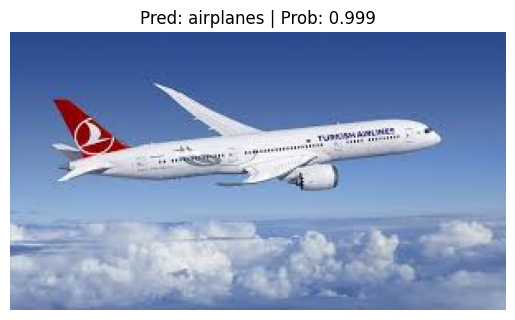

In [ ]:
transform_predict(model = pretrained_vit,
                  class_names = class_names,
                  image_path = thy_path,
                  device = device
                  )